### Optimal control of the Wilson-Cowan model
This notebook shows how to compute the optimal control (OC) signal for the Wilson-Cowan model for a simple example task.

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import os

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc
from neurolib.utils.plot_oc import plot_oc_singlenode, plot_oc_network, plot_wb_nw

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We stimulate the system with a known control signal, define the resulting activity as target, and compute the optimal control for this target. We define weights such that precision is penalized only (w_p=1, w_2=0). Hence, the optimal control signal should converge to the input signal.

In [2]:
# We import the model
model = WCModel()

# Some parameters to define stimulation signals
dt = model.params["dt"]
duration = 10.
amplitude = 1.
period = duration /4.

# We define a "zero-input", and a sine-input
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
input[0,1:-1] = amplitude * np.sin(2.*np.pi*np.arange(0,duration-0.1, dt)/period) # other functions or random values can be used as well

# We set the duration of the simulation and the initial values
model.params["duration"] = duration
x_init = 0.011225367461896877
y_init = 0.013126741089502588
model.params["exc_init"] = np.array([[x_init]])
model.params["inh_init"] = np.array([[y_init]])

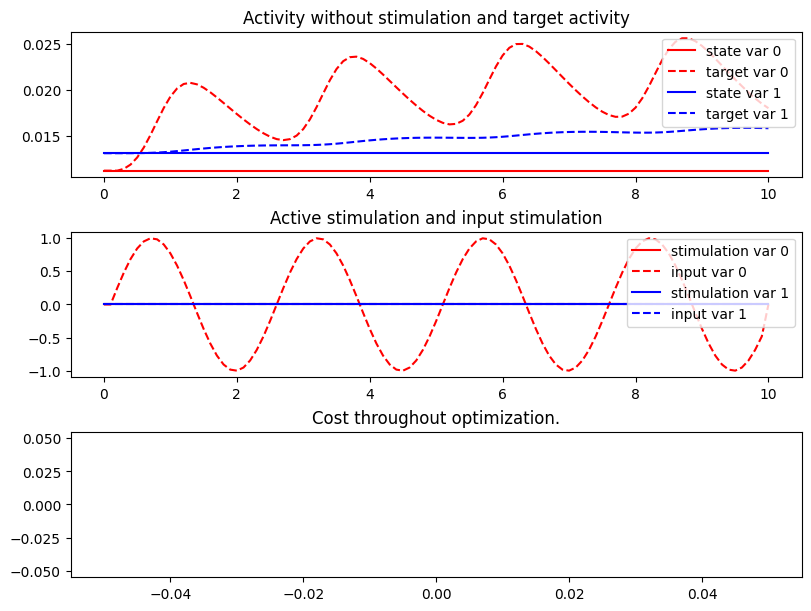

In [4]:
# We set the stimulus in x and y variables, and run the simulation
model.params["exc_ext"] = input
model.params["inh_ext"] = zero_input
model.run()

# Define the result of the stimulation as target
target = np.concatenate((np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis],
    np.stack( (model.exc, model.inh), axis=1)), axis=2)
target_input = np.concatenate( (input,zero_input), axis=0)[np.newaxis,:,:]

# Remove stimuli and re-run the simulation
model.params["exc_ext"] = zero_input
model.params["inh_ext"] = zero_input
control = np.concatenate( (zero_input,zero_input), axis=0)[np.newaxis,:,:]
model.run()

# combine initial value and simulation result to one array
state = np.concatenate((np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis],
    np.stack( (model.exc, model.inh), axis=1)), axis=2)

plot_oc_singlenode(duration, dt, state, target, control, target_input)

Compute control for a deterministic system
Cost in iteration 0: 0.000418105541982903
Cost in iteration 25: 1.053210245410925e-05
Cost in iteration 50: 3.925315729100599e-06
Cost in iteration 75: 2.1054588334476985e-06
Cost in iteration 100: 1.3983206941835164e-06
Cost in iteration 125: 1.0229387100204474e-06
Cost in iteration 150: 7.974333735234601e-07
Cost in iteration 175: 6.52111534026685e-07
Cost in iteration 200: 5.444869100157724e-07
Cost in iteration 225: 4.645365102998247e-07
Cost in iteration 250: 4.0173389305014e-07
Cost in iteration 275: 3.5110841320809565e-07
Cost in iteration 300: 3.096084004886465e-07
Cost in iteration 325: 2.7522197728167194e-07
Cost in iteration 350: 2.4661222175044866e-07
Cost in iteration 375: 2.2171404739101127e-07
Cost in iteration 400: 2.0072190143053785e-07
Cost in iteration 425: 1.8306021177635466e-07
Cost in iteration 450: 1.668165187773572e-07
Cost in iteration 475: 1.5334951215980564e-07
Cost in iteration 500: 1.4092613745894185e-07
Final cost

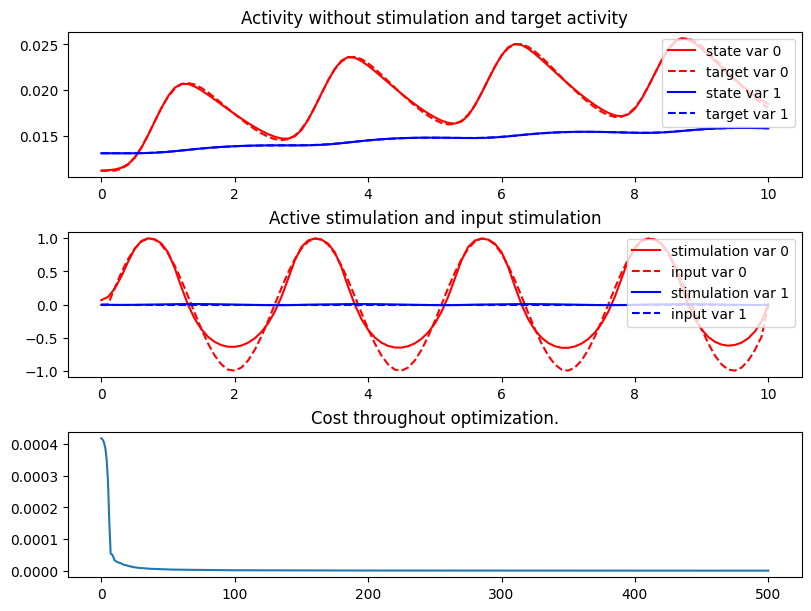

In [5]:
# We set the external stimulation to zero. This is the "initial guess" for the OC algorithm
model.params["exc_ext"] = zero_input
model.params["inh_ext"] = zero_input

# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,501,25))
model_controlled.weights["w_p"] = 1. # default value 1
model_controlled.weights["w_2"] = 0. # default value 0

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(500)

state = model_controlled.get_xs()
control = model_controlled.control

plot_oc_singlenode(duration, dt, state, target, control, target_input, model_controlled.cost_history)

Compute control for a deterministic system
Cost in iteration 0: 1.4092613745894185e-07
Cost in iteration 25: 1.3051113114486598e-07
Cost in iteration 50: 1.2069164098268006e-07
Cost in iteration 75: 1.1215971283577444e-07
Cost in iteration 100: 1.04563274527841e-07
Final cost : 1.04563274527841e-07


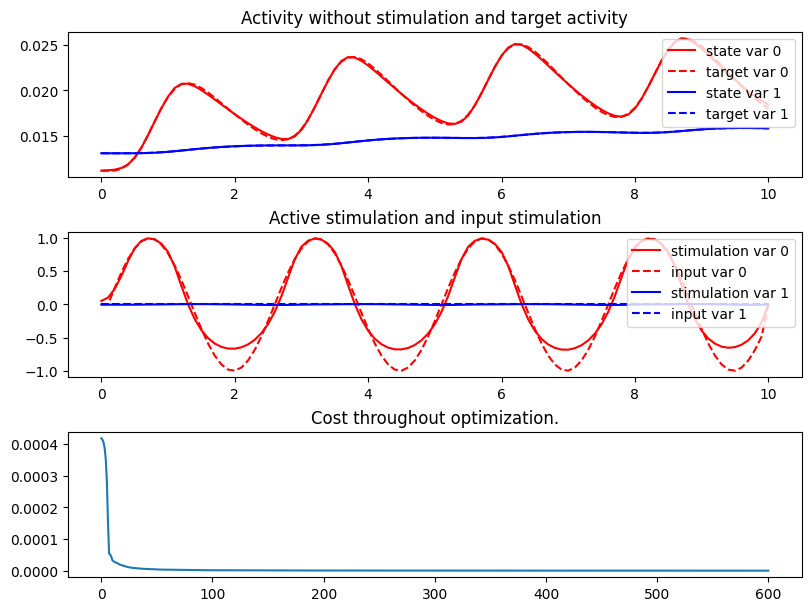

In [6]:
# Do another 100 iterations if you want to.
# Repeated execution will continue with further 100 iterations.
model_controlled.optimize(100)
state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_singlenode(duration, dt, state, target, control, target_input, model_controlled.cost_history)

### Network case

Let us know study a simple 2-node network of model oscillators. We first define the coupling matrix and the distance matrix. We can then initialize the model.

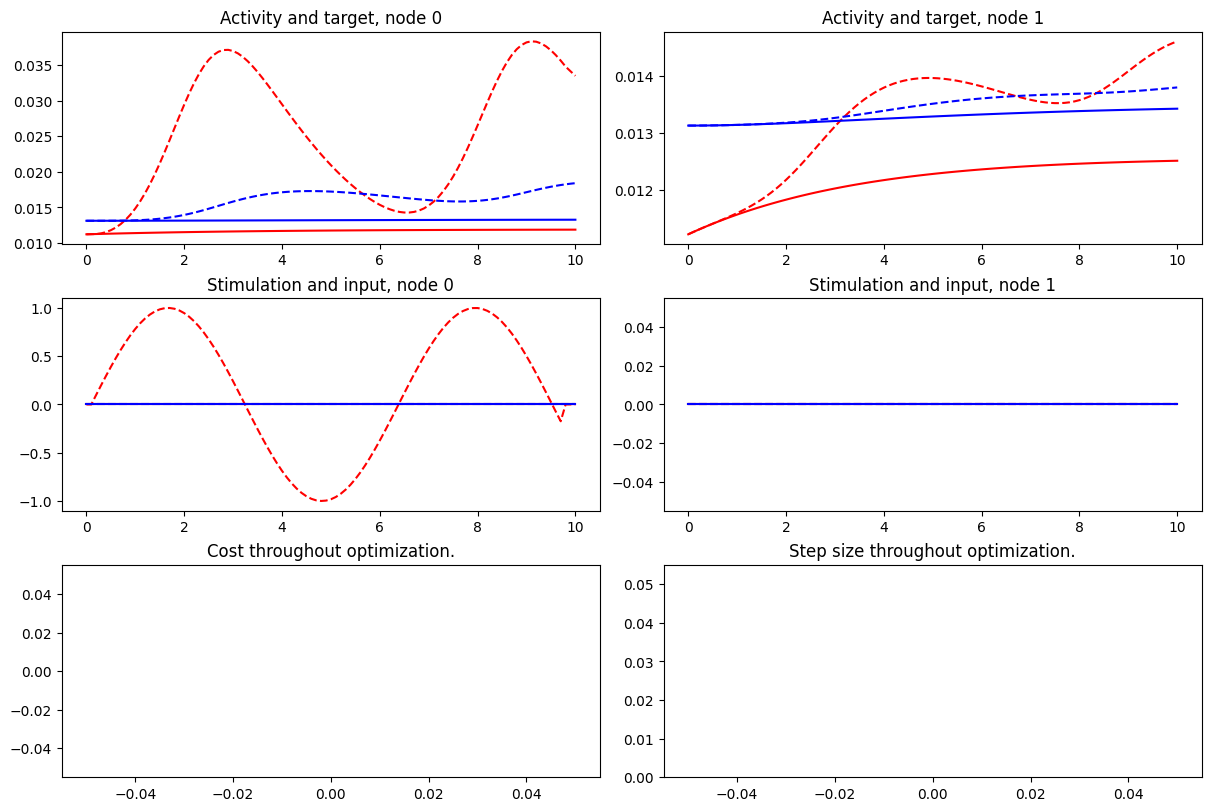

In [7]:
cmat = np.array( [[0., 0.5], [1., 0.]] )  # diagonal elements are zero, connection strength is 1 (0.5) from node 0 to node 1 (from node 1 to node 0)
dmat = np.array( [[0., 0.], [0., 0.]] )  # no delay

model = WCModel(Cmat=cmat, Dmat=dmat)

# we define the control input matrix to enable or disable certain channels and nodes
control_mat = np.zeros( (model.params.N, len(model.state_vars)) )
control_mat[0,0] = 1. # only allow inputs in x-channel in node 0

model.params.K_gl = 5.

model.params["duration"] = duration
zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = np.copy(zero_input)
input[0,1:-3] = np.sin(np.arange(0,duration-0.3, dt)) # other functions or random values can be used as well
model.params["exc_init"] = np.vstack( [x_init, x_init] )
model.params["inh_init"] = np.vstack( [y_init, y_init] )


# We set the stimulus in x and y variables, and run the simulation
input_nw = np.concatenate( (np.vstack( [control_mat[0,0] * input, control_mat[0,1] * input] )[np.newaxis,:,:],
                            np.vstack( [control_mat[1,0] * input, control_mat[1,1] * input] )[np.newaxis,:,:]), axis=0)
zero_input_nw = np.concatenate( (np.vstack( [zero_input, zero_input] )[np.newaxis,:,:],
                                 np.vstack( [zero_input, zero_input] )[np.newaxis,:,:]), axis=0)

model.params["exc_ext"] = input_nw[:,0,:]
model.params["inh_ext"] = input_nw[:,1,:]

model.run()

# Define the result of the stimulation as target
target = np.concatenate( (np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)

# Remove stimuli and re-run the simulation
model.params["exc_ext"] = zero_input_nw[:,0,:]
model.params["inh_ext"] = zero_input_nw[:,0,:]
model.run()

# combine initial value and simulation result to one array
state =  np.concatenate( (np.concatenate( (model.params["exc_init"], model.params["inh_init"]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)

plot_oc_network(model.params.N, duration, dt, state, target, zero_input_nw, input_nw)

Compute control for a deterministic system
Cost in iteration 0: 8.117061134315108e-06
Cost in iteration 25: 3.991029159085846e-07
Cost in iteration 50: 2.0940293478671185e-07
Cost in iteration 75: 1.11776566406223e-07
Cost in iteration 100: 6.633087062703058e-08
Cost in iteration 125: 3.767129904338891e-08
Cost in iteration 150: 2.337898889177354e-08
Cost in iteration 175: 1.6124862923969687e-08
Cost in iteration 200: 1.1647682670737143e-08
Cost in iteration 225: 8.926692122664385e-09
Cost in iteration 250: 7.0546661142583194e-09
Cost in iteration 275: 5.8200152315059315e-09
Cost in iteration 300: 4.860088153479947e-09
Cost in iteration 325: 4.1868184248475905e-09
Cost in iteration 350: 3.671234703393019e-09
Cost in iteration 375: 3.2820026741717433e-09
Cost in iteration 400: 2.970711301045303e-09
Cost in iteration 425: 2.7216367205111153e-09
Cost in iteration 450: 2.5182704941078486e-09
Cost in iteration 475: 2.350788582742496e-09
Cost in iteration 500: 2.2010686605823463e-09
Final co

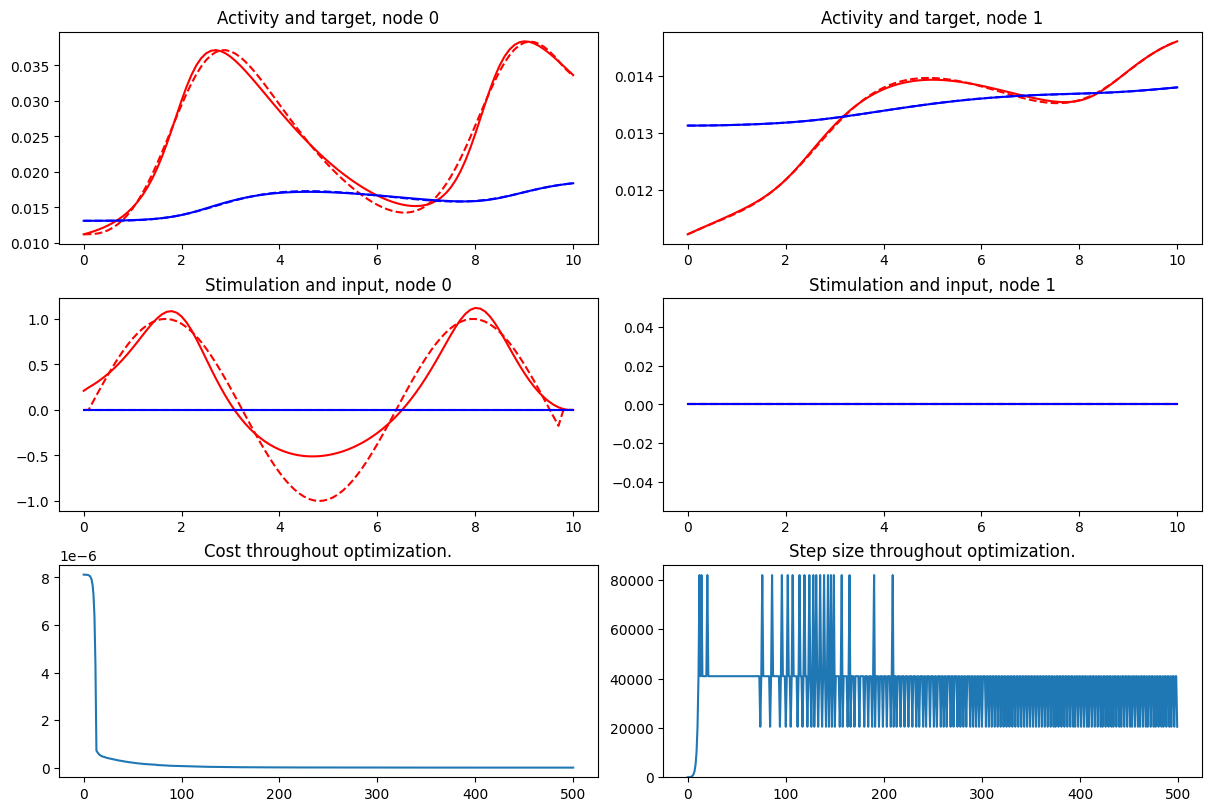

In [8]:
# we define the precision matrix to specify, in which nodes and channels we measure deviations from the target
cost_mat = np.zeros( (model.params.N, len(model.output_vars)) )
cost_mat[1,0] = 1. # only measure in y-channel in node 1

# We set the external stimulation to zero. This is the "initial guess" for the OC algorithm
model.params["exc_ext"] = zero_input_nw[:,0,:]
model.params["inh_ext"] = zero_input_nw[:,0,:]

# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,501,25), control_matrix=control_mat, cost_matrix=cost_mat)

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(500)

state = model_controlled.get_xs()
control = model_controlled.control

plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

Compute control for a deterministic system
Cost in iteration 0: 2.2010686605823463e-09
Cost in iteration 25: 2.0784520596404367e-09
Cost in iteration 50: 1.966749124035962e-09
Cost in iteration 75: 1.870038718444721e-09
Cost in iteration 100: 1.7873019174123556e-09
Final cost : 1.7873019174123556e-09


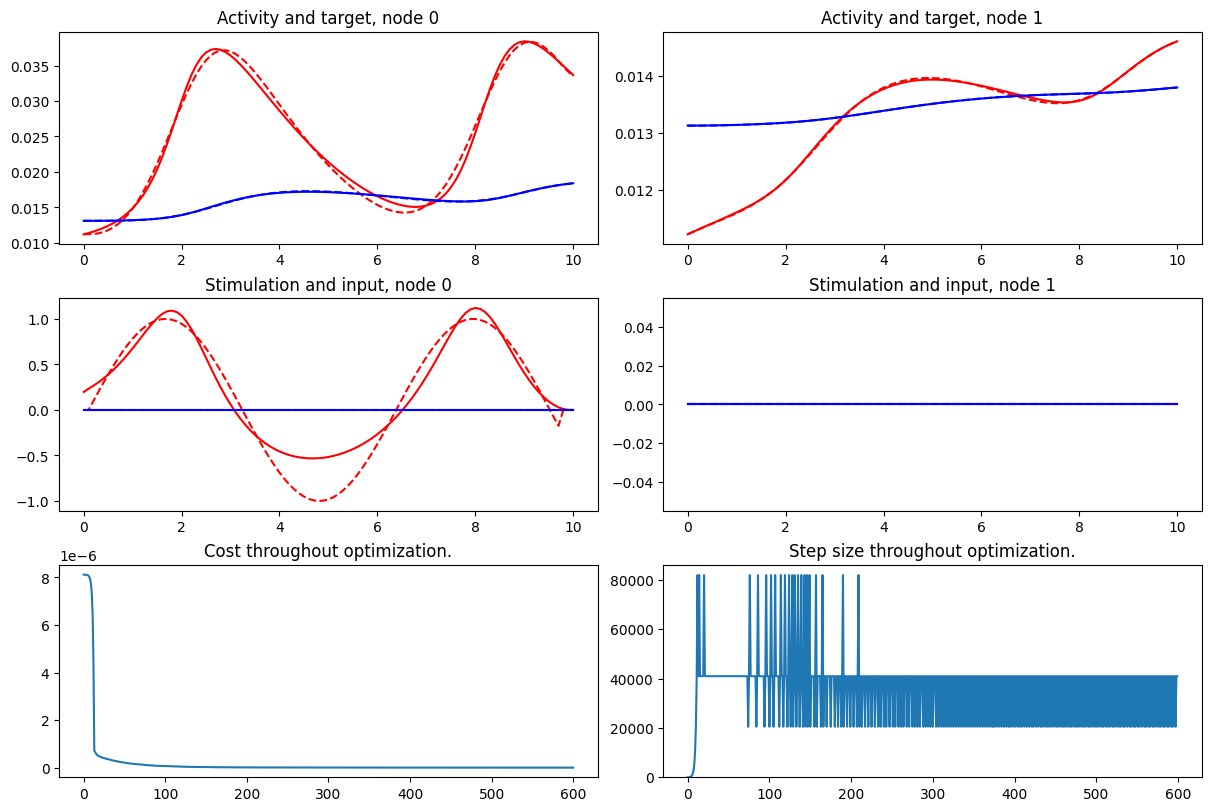

In [9]:
# Do another 100 iterations if you want to.
# Repeated execution will continue with further 100 iterations.
model_controlled.optimize(100)
state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

### Delayed network of neural populations

We now consider a network topology with delayed signalling between the two nodes.

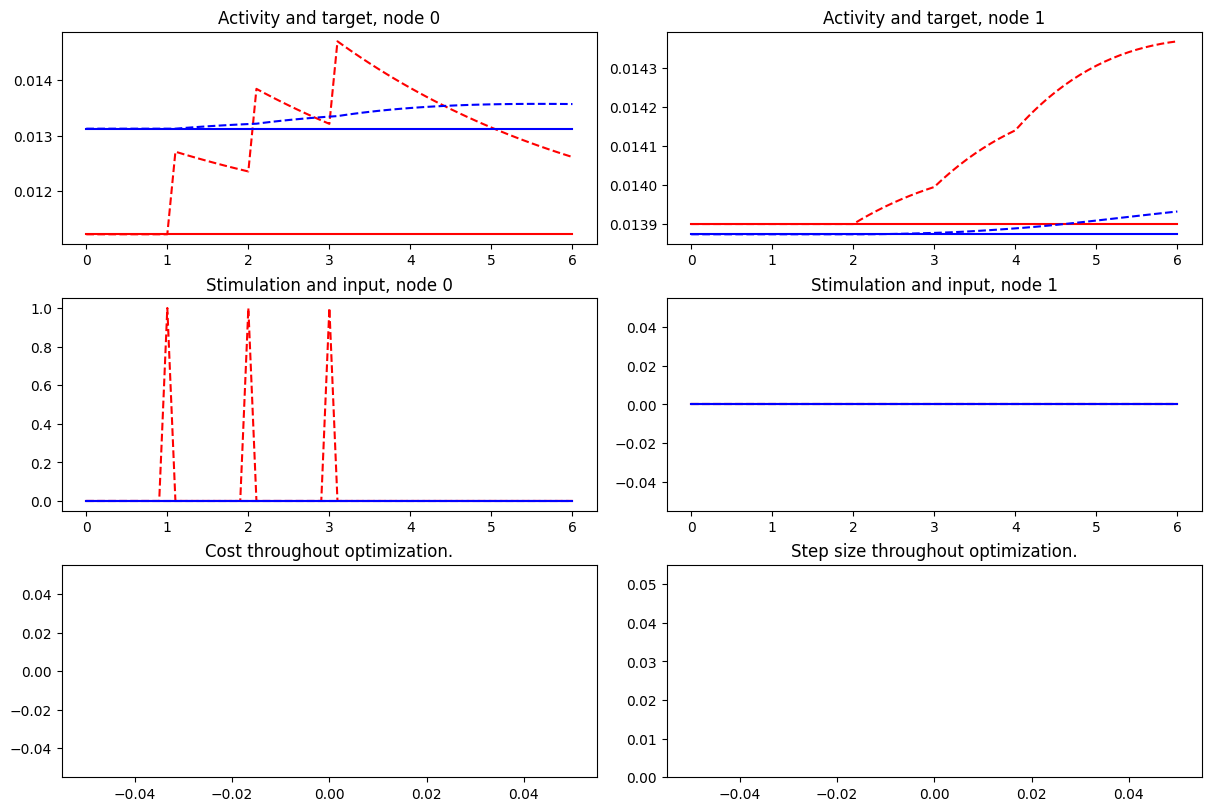

In [10]:
cmat = np.array( [[0., 0.], [1., 0.]] ) # diagonal elements are zero, connection strength is 1 from node 0 to node 1
dmat = np.array( [[0., 0.], [18, 0.]] ) # distance from 0 to 1, delay is computed by dividing by the signal speed params.signalV

model = WCModel(Cmat=cmat, Dmat=dmat)

duration, dt = 2000., 0.1
model.params.duration = duration
model.params.dt = dt
model.params.K_gl = 10.

model.run()

e0 = model.exc[0,-1]
e1 = model.exc[1,-1]
i0 = model.inh[0,-1]
i1 = model.inh[1,-1]

maxdelay = model.getMaxDelay()

model.params["exc_init"] = np.array([[e0] * (maxdelay + 1), [e1] * (maxdelay + 1) ])
model.params["inh_init"] = np.array([[i0] * (maxdelay + 1), [i1] * (maxdelay + 1) ])

duration = 6.
model.params.duration = duration
model.run()

# we define the control input matrix to enable or disable certain channels and nodes
control_mat = np.zeros( (model.params.N, len(model.state_vars)) )
control_mat[0,0] = 1. # only allow inputs in E-channel in node 0

zero_input = ZeroInput().generate_input(duration=duration+dt, dt=dt)
input = zero_input.copy()
input[0,10] = 1. 
input[0,20] = 1.
input[0,30] = 1. # Three pulses as control input

input_nw = np.concatenate( (np.vstack( [control_mat[0,0] * input, control_mat[0,1] * input] )[np.newaxis,:,:],
                            np.vstack( [control_mat[1,0] * input, control_mat[1,1] * input] )[np.newaxis,:,:]), axis=0)
zero_input_nw = np.concatenate( (np.vstack( [zero_input, zero_input] )[np.newaxis,:,:],
                                 np.vstack( [zero_input, zero_input] )[np.newaxis,:,:]), axis=0)

model.params["exc_ext"] = input_nw[:,0,:]
model.params["inh_ext"] = input_nw[:,1,:]
model.run()

# Define the result of the stimulation as target
target = np.concatenate( (np.stack( (model.params["exc_init"][:,-1], model.params["inh_init"][:,-1]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)

# Remove stimuli and re-run the simulation
model.params["exc_ext"] = zero_input_nw[:,0,:]
model.params["inh_ext"] = zero_input_nw[:,0,:]
model.run()

# combine initial value and simulation result to one array
state = np.concatenate( (np.stack( (model.params["exc_init"][:,-1], model.params["inh_init"][:,-1]), axis=1)[:,:, np.newaxis], np.stack( (model.exc, model.inh), axis=1)), axis=2)
plot_oc_network(model.params.N, duration, dt, state, target, zero_input_nw, input_nw)

Compute control for a deterministic system
Cost in iteration 0: 1.7928350533912262e-07
Cost in iteration 25: 3.261640346841477e-10
Cost in iteration 50: 1.0779524630417724e-10
Cost in iteration 75: 8.574159593586424e-11
Cost in iteration 100: 7.606917593646062e-11
Cost in iteration 125: 7.030832625940234e-11
Cost in iteration 150: 6.604190402100834e-11
Cost in iteration 175: 6.251353168542466e-11
Cost in iteration 200: 5.957299348104675e-11
Cost in iteration 225: 5.679788234926844e-11
Cost in iteration 250: 5.436441341054896e-11
Cost in iteration 275: 5.220943426960374e-11
Cost in iteration 300: 5.028985793307416e-11
Cost in iteration 325: 4.857204489591882e-11
Cost in iteration 350: 4.708332788067809e-11
Cost in iteration 375: 4.566199765058689e-11
Cost in iteration 400: 4.438717405720476e-11
Cost in iteration 425: 4.323698275134953e-11
Cost in iteration 450: 4.2194754152020387e-11
Cost in iteration 475: 4.12460884276137e-11
Cost in iteration 500: 4.0379430193142616e-11
Final cost : 4

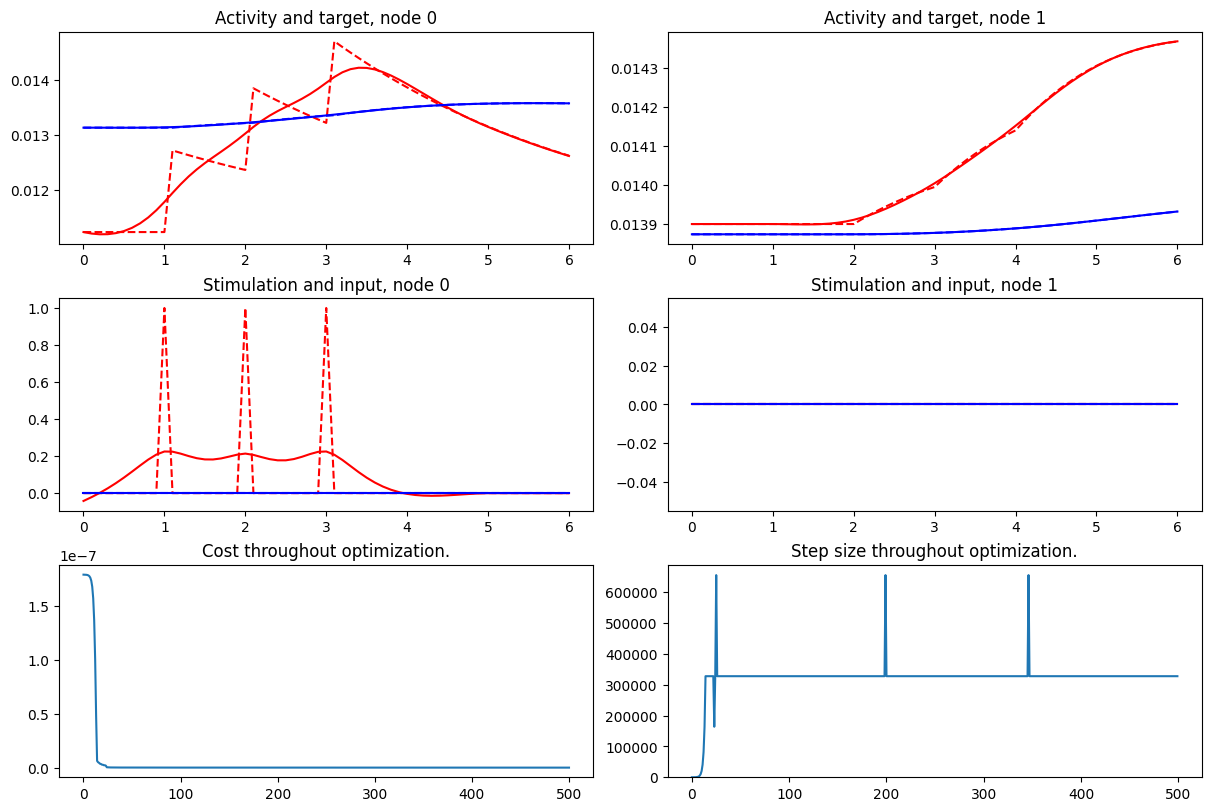

In [11]:
# We load the optimal control class
# print array (optional parameter) defines, for which iterations intermediate results will be printed
# Parameters will be taken from the input model
model_controlled = oc_wc.OcWc(model, target, print_array=np.arange(0,501,25), control_matrix=control_mat, cost_matrix=cost_mat)

# We run 500 iterations of the optimal control gradient descent algorithm
model_controlled.optimize(500)

state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

Compute control for a deterministic system
Cost in iteration 0: 4.0379430193142616e-11
Cost in iteration 25: 3.958449761829644e-11
Cost in iteration 50: 3.885283256315931e-11
Cost in iteration 75: 3.8176788194032465e-11
Cost in iteration 100: 3.755000697286012e-11
Final cost : 3.755000697286012e-11


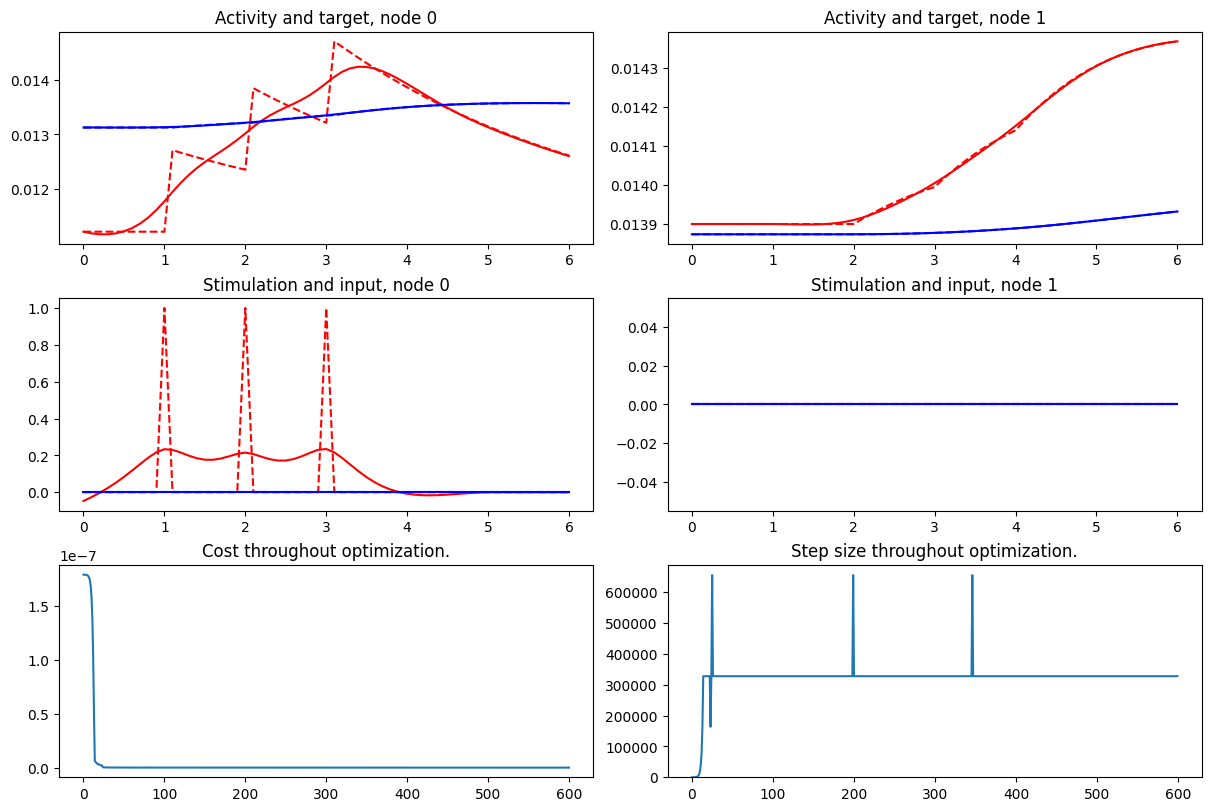

In [12]:
# perofrm another 100 iterations to improve result
# repeat execution to add another 500 iterations
# converence to the input stimulus is relatively slow for the WC nodel
model_controlled.optimize(100)
state = model_controlled.get_xs()
control = model_controlled.control
plot_oc_network(model.params.N, duration, dt, state, target, control, input_nw, model_controlled.cost_history, model_controlled.step_sizes_history)

### Whole-brain network model: force oscillations

We construct a whole-brain network model and force it to oscillate, starting from a state of constant high or low activity.

In [ ]:
from neurolib.utils.loadData import Dataset
ds = Dataset("hcp")  #alternatively, you can use Dataset("gw")

model = WCModel(Cmat = ds.Cmat, Dmat = ds.Dmat)
duration = 100.
model.params['duration'] = duration
model.params['K_gl'] = 1.0

In [ ]:
# set static external input to find a state of constant high activity
model.params['exc_ext_baseline'] = 0.
model.params['inh_ext_baseline'] = 1.

# for up state, chose e_ext = 3, i_ext = 0

model.run()
N = model.params.N

for n in range(N):
    model.params["exc_init"][n,-1] = model.exc[n, -1]
    model.params["inh_init"][n,-1] = model.inh[n, -1]

model.run()

In [35]:
# set target oscillation period
target_period = 20.

# set cost matrix and control matrix
cost_mat = np.zeros( (model.params.N, len(model.output_vars)) )
cost_mat[:,0] = 1. # only measure in exc channel in all nodes

control_mat = np.zeros( (model.params.N, len(model.input_vars)) )
control_mat[:,0] = 1. # only enable inputs to exc channel in all nodes

# set control interval to [10, 90]
control_interval = [100, 900]

control_init = np.zeros((N, 2, int(duration/model.params.dt)+1))
for n in range(N):
    control_init[n,0,control_interval[0]:control_interval[1]] = 0.5*(1. + np.sin(np.linspace(-0.5*np.pi, 7.5*np.pi, control_interval[1] - control_interval[0])))

We first compute the control using the enery cost. This will yield control signals that target all network nodes at low input strength.

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 765.6559862607954
Cost in iteration 1: -75577.52624124991
Final cost : -75577.52624124991
Compute control for a deterministic system
Cost in iteration 0: -18742.87018453326
Cost in iteration 1: -19014.865025841536
Cost in iteration 2: -62777.31707175118
Final cost : -62777.31707175118
Compute control for a deterministic system
Cost in iteration 0: 1711.1118531192005
Cost in iteration 1: -18510.20608248251
Cost in iteration 2: -19284.437180645054
Final cost : -19284.437180645054
Compute control for a deterministic system
Cost in iteration 0: 248.7856430475622
Cost in iteration 1: -974.291498306131
Cost in iteration 2: -2768.956160274458
Final cost : -2768.956160274458
Compute control for a deterministic system
Cost in iteration 0: 1939.6552195728218
Cost in iteration 1: 1548.424367753063
Cost in iteration 2: 1012.8015002687644
Final cost : 1012.8015002687644


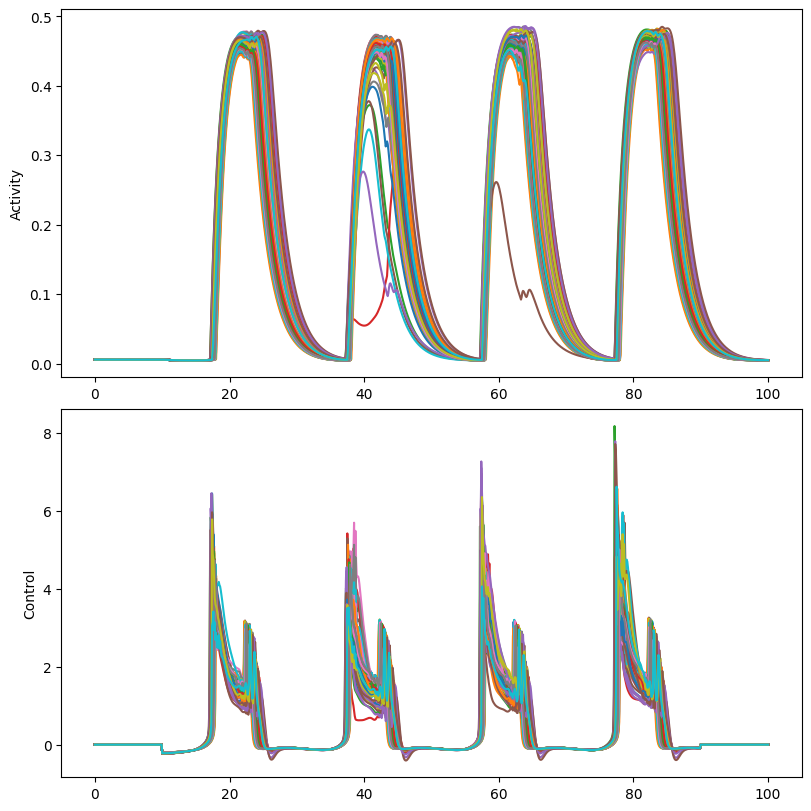

In [ ]:
model_controlled_e = oc_wc.OcWc(model, target_period, print_array=np.arange(0,101,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=[100, 900])
model_controlled_e.weights["w_p"] = 0.
model_controlled_e.weights["w_2"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"
model_controlled_e.control = control_init.copy()
model_controlled_e.update_input()

# we iteratively adjust the weight
model_controlled_e.weights["w_f"] = 2*1e7
model_controlled_e.optimize(1)

model_controlled_e.weights["w_f"] = 1e7
model_controlled_e.optimize(2)

model_controlled_e.weights["w_f"] = 3. * 1e6
model_controlled_e.optimize(2)

model_controlled_e.weights["w_f"] = 1e6
model_controlled_e.optimize(2)

model_controlled_e.weights["w_f"] = 5. * 1e5
model_controlled_e.optimize(3)

state = model_controlled_e.get_xs()
control = model_controlled_e.control
plot_wb_nw(state, control, duration, model_controlled_e.model.params.dt)

Compute control for a deterministic system
Cost in iteration 0: -576.3322976861377
Cost in iteration 1: -576.3404575784298
Cost in iteration 2: -576.3409354885262
Cost in iteration 3: -576.3478070984825
Cost in iteration 4: -576.3916774032878
Cost in iteration 5: -576.3952393254817
Cost in iteration 6: -576.3988429929586
Cost in iteration 7: -576.4101594200465
Cost in iteration 8: -576.4137518892826
Cost in iteration 9: -576.4253097065366
Cost in iteration 10: -576.429926879674
Cost in iteration 11: -576.4330010734261
Cost in iteration 12: -576.4430078565856
Cost in iteration 13: -576.444513878334
Cost in iteration 14: -576.4538180664913
Cost in iteration 15: -576.4598783171937
Cost in iteration 16: -576.4624739425021
Cost in iteration 17: -576.4714536377892
Cost in iteration 18: -576.4728123058603
Cost in iteration 19: -576.482055470407
Cost in iteration 20: -576.4825995898018
Final cost : -576.4825995898018
Compute control for a deterministic system
Cost in iteration 0: -576.48259958

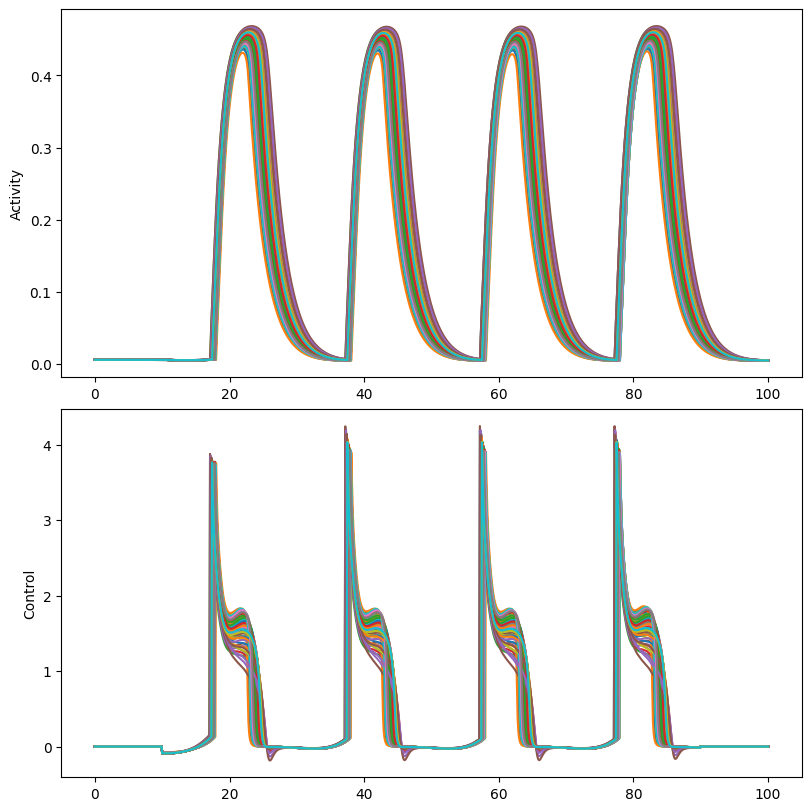

In [ ]:
# re-run this code to run another 20 iterations
model_controlled_e.channelwise_optimization = False
model_controlled_e.optimize(20)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_e.channelwise_optimization = True
model_controlled_e.optimize(4)

state = model_controlled_e.get_xs()
control = model_controlled_e.control
plot_wb_nw(state, control, duration, model_controlled_e.model.params.dt)

We then compute the control using the directional sparsity cost. This will yield control signals that target a subset of network nodes.

Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 329.6930956553957
Cost in iteration 1: -36446.96516081985
Final cost : -36446.96516081985
Compute control for a deterministic system
Cost in iteration 0: -6110.094161183185
Cost in iteration 1: -6969.707047364747
Cost in iteration 2: -7926.21463250845
Final cost : -7926.21463250845
Compute control for a deterministic system
Cost in iteration 0: 80.72572795015776
Cost in iteration 1: -1367.365523125562
Cost in iteration 2: -1676.2915568474882
Cost in iteration 3: -1696.7915510880987
Cost in iteration 4: -1899.1183591485744
Cost in iteration 5: -1913.9000036866378
Final cost : -1913.9000036866378
Compute control for a deterministic system
Cost in iteration 0: -760.8480168879682
Cost in iteration 1: -974.2893581079327
Cost in iteration 2: -1015.8808296917916
Cost in iteration 3: -1096.328982992097
Cost in iteration 4: -1105.5160422432864
Cost in iteration 5: -1151.8530037734977
F

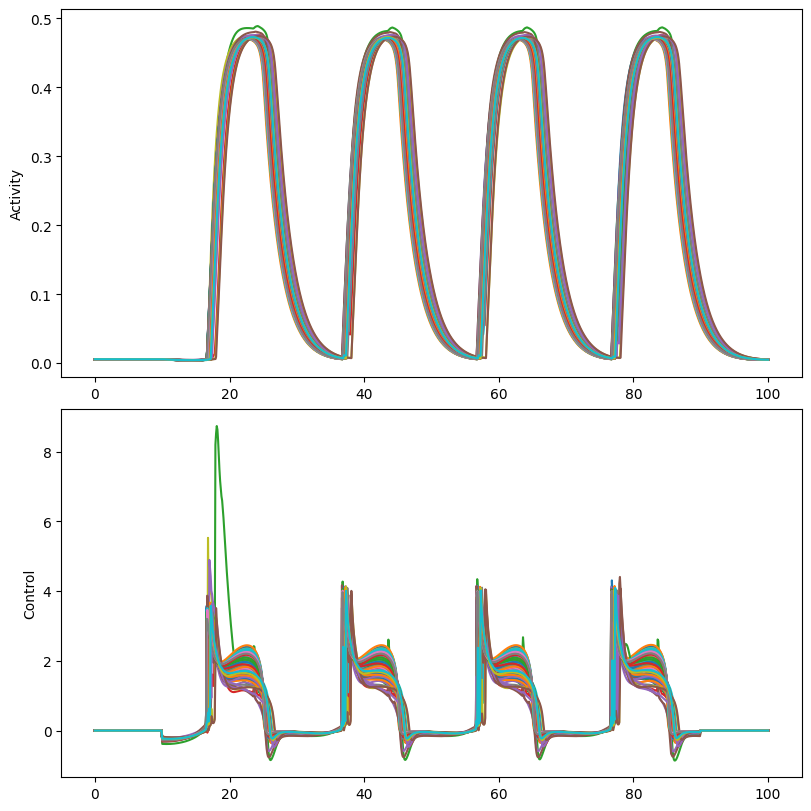

In [ ]:
model_controlled_ds = oc_wc.OcWc(model, target_period, print_array=np.arange(0,101,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=[100, 900])
model_controlled_ds.weights["w_p"] = 0.
model_controlled_ds.weights["w_1D"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"
model_controlled_ds.control = control_init.copy()
model_controlled_ds.update_input()

# we iteratively adjust the weight
model_controlled_ds.weights["w_f"] = 5. * 1e6
model_controlled_ds.optimize(1)

model_controlled_ds.weights["w_f"] = 1. * 1e6
model_controlled_ds.optimize(2)

model_controlled_ds.weights["w_f"] = 3. * 1e5
model_controlled_ds.optimize(5)

model_controlled_ds.weights["w_f"] = 2. * 1e5
model_controlled_ds.optimize(5)

model_controlled_ds.weights["w_f"] = 1. * 1e5
model_controlled_ds.optimize(5)

state = model_controlled_ds.get_xs()
control = model_controlled_ds.control
plot_wb_nw(state, control, duration, model_controlled_ds.model.params.dt)

Compute control for a deterministic system
Cost in iteration 0: -118.93469063392934
Cost in iteration 1: -122.54306913528842
Cost in iteration 2: -123.9478804261172
Cost in iteration 3: -124.66909837371452
Cost in iteration 4: -126.63101971763638
Cost in iteration 5: -127.0435833813965
Cost in iteration 6: -127.77269964975312
Cost in iteration 7: -128.39812878043028
Cost in iteration 8: -128.77790274672827
Cost in iteration 9: -128.97880569605934
Cost in iteration 10: -129.12959953467816
Cost in iteration 11: -129.19104564159443
Cost in iteration 12: -129.5043725315311
Cost in iteration 13: -129.5944581039637
Cost in iteration 14: -129.73142314340976
Cost in iteration 15: -129.80435617796945
Cost in iteration 16: -129.89889498815114
Cost in iteration 17: -129.96003029931808
Cost in iteration 18: -129.99310346649042
Cost in iteration 19: -130.012791648713
Cost in iteration 20: -130.13994718608853
Final cost : -130.13994718608853
Compute control for a deterministic system
Cost in iterati

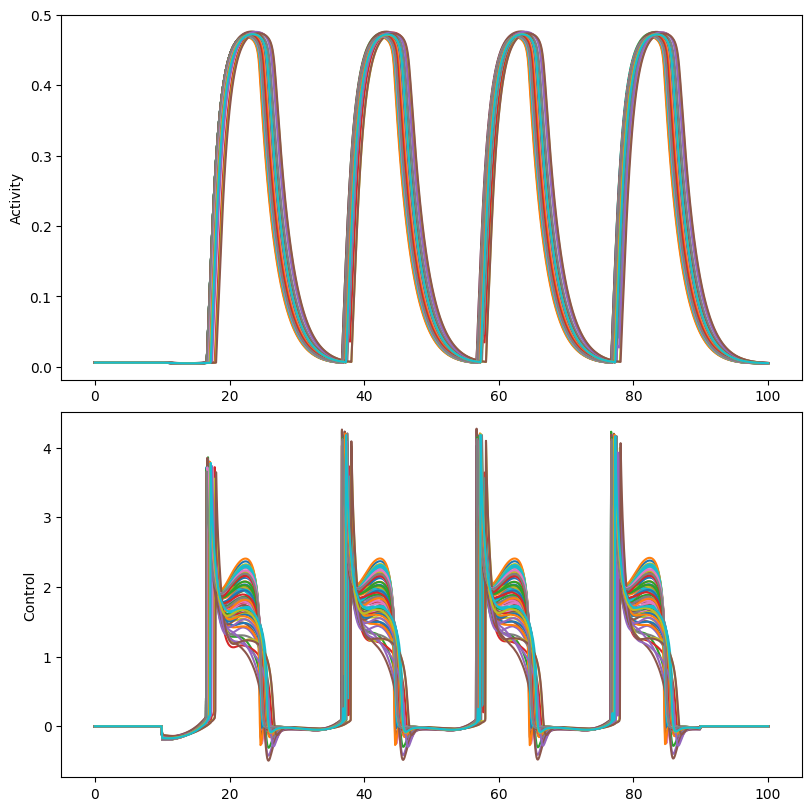

In [97]:
# re-run this code to run another 20 iterations
model_controlled_ds.channelwise_optimization = False
model_controlled_ds.optimize(20)

# channelwise optimization for independent optimization in all channels. This takes much longer, but will, in the end, improve results
model_controlled_ds.channelwise_optimization = True
model_controlled_ds.optimize(20)

state = model_controlled_ds.get_xs()
control = model_controlled_ds.control
plot_wb_nw(state, control, duration, model_controlled_ds.model.params.dt)

We then compute the control using the temporal sparsity cost. This will yield control signals that are nonzero only during short time spans during the control time interval

model_controlled_ts = oc_wc.OcWc(model, target_period, print_array=np.arange(0,101,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=[100, 900])
model_controlled_ts.weights["w_p"] = 0.
model_controlled_ts.weights["w_1T"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"
model_controlled_ds.control = control_init.copy()
model_controlled_ds.update_input()

# we iteratively adjust the weight
model_controlled_ds.weights["w_f"] = 5. * 1e6
model_controlled_ds.optimize(1)

model_controlled_ds.weights["w_f"] = 1. * 1e6
model_controlled_ds.optimize(2)

model_controlled_ds.weights["w_f"] = 3. * 1e5
model_controlled_ds.optimize(5)

model_controlled_ds.weights["w_f"] = 2. * 1e5
model_controlled_ds.optimize(5)

model_controlled_ds.weights["w_f"] = 1. * 1e5
model_controlled_ds.optimize(5)

state = model_controlled_ds.get_xs()
control = model_controlled_ds.control
plot_wb_nw(state, control, duration, model_controlled_ds.model.params.dt)

In [ ]:
model_controlled_ts = oc_wc.OcWc(model, target_period, print_array=np.arange(0,101,1), control_matrix=control_mat, cost_matrix=cost_mat, control_interval=[100, 900])
model_controlled_ts.weights["w_p"] = 0.
model_controlled_ts.weights["w_1T"] = 1. #use weights["w_2"], weights["w_1D"] or weights["w_1TS"] for energy, directional or temporal sparsity cost"
model_controlled_ts.control = control_init.copy()
model_controlled_ts.update_input()

# we iteratively adjust the weight
model_controlled_ts.weights["w_f"] = 5. * 1e6
model_controlled_ts.optimize(1)

model_controlled_ts.weights["w_f"] = 1. * 1e6
model_controlled_ts.optimize(2)

model_controlled_ts.weights["w_f"] = 3. * 1e5
model_controlled_ts.optimize(5)

model_controlled_ts.weights["w_f"] = 2. * 1e5
model_controlled_ts.optimize(5)

model_controlled_ts.weights["w_f"] = 1. * 1e5
model_controlled_ts.optimize(5)

state = model_controlled_ts.get_xs()
control = model_controlled_ts.control
plot_wb_nw(state, control, duration, model_controlled_ts.model.params.dt)